In [88]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import os 
import re
df= pd.read_csv('abalone.data')

In [89]:
# Add column names manually (from abalone.names file)
df.columns = [
    "Sex", "Length", "Diameter", "Height",
    "WholeWeight", "ShuckedWeight", "VisceraWeight",
    "ShellWeight", "Rings"
]

# print(df.head())


In [90]:
df

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.1200,8
...,...,...,...,...,...,...,...,...,...
4171,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4172,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4173,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4174,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


<Axes: >

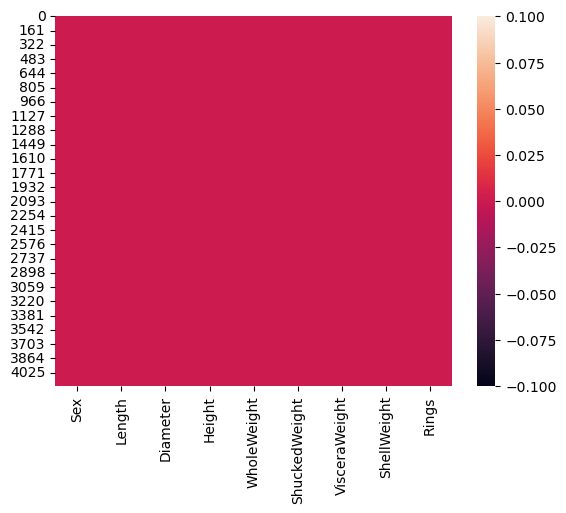

In [91]:
import seaborn as sns
sns.heatmap(df.isnull())


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4176 entries, 0 to 4175
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4176 non-null   object 
 1   Length         4176 non-null   float64
 2   Diameter       4176 non-null   float64
 3   Height         4176 non-null   float64
 4   WholeWeight    4176 non-null   float64
 5   ShuckedWeight  4176 non-null   float64
 6   VisceraWeight  4176 non-null   float64
 7   ShellWeight    4176 non-null   float64
 8   Rings          4176 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [93]:
df.describe()

,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
count,4176.000000,4176.000000,4176.000000,4176.000000,4176.00000,4176.000000,4176.000000,4176.000000
mean,0.524009,0.407892,0.139527,0.828818,0.35940,0.180613,0.238852,9.932471
std,0.120103,0.099250,0.041826,0.490424,0.22198,0.109620,0.139213,3.223601
min,0.075000,0.055000,0.000000,0.002000,0.00100,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.18600,0.093375,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799750,0.33600,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153250,0.50200,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.48800,0.760000,1.005000,29.000000


In [94]:
# sns.heatmap(df.isnull(), cbar = False, cmap = 'c')

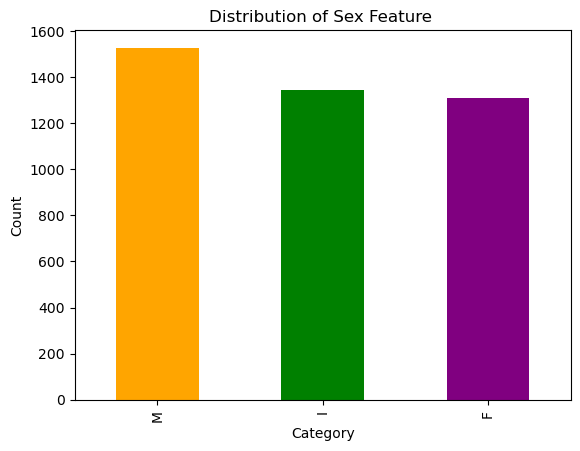

In [95]:
df['Sex'].value_counts().plot(kind = 'bar',color = ['orange','green','purple'])
plt.title("Distribution of Sex Feature ")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

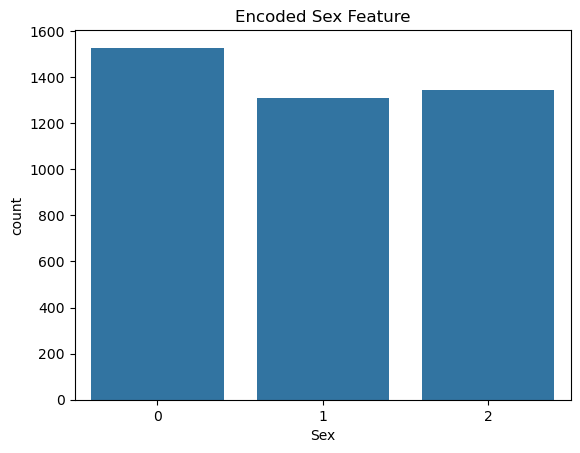

In [96]:
df['Sex'] = df['Sex'].map({"M":0, "F" :1,"I":2})
sns.countplot(x = "Sex", data = df)
plt.title("Encoded Sex Feature")
plt.show()

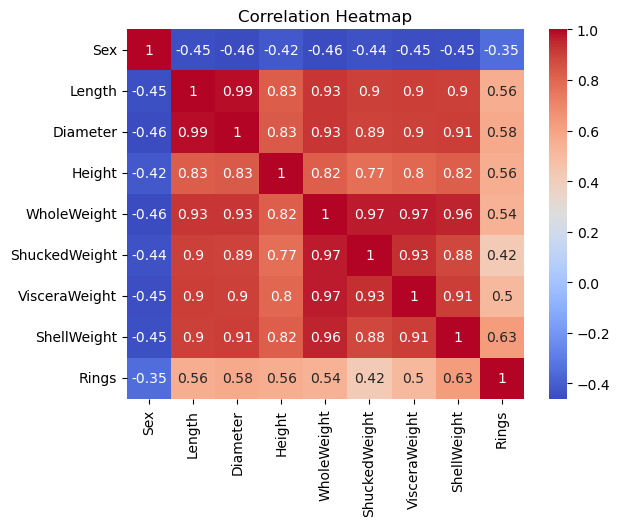

In [97]:
corr = df.corr()
sns.heatmap(corr,annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

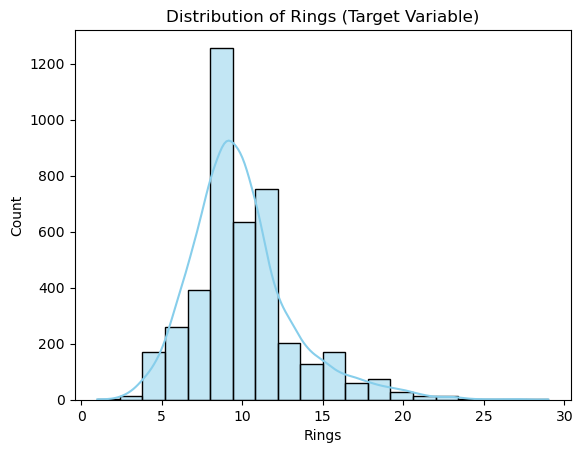

In [98]:
sns.histplot(df['Rings'],bins = 20, kde = True, color = 'skyblue')
plt.title("Distribution of Rings (Target Variable)")
plt.show()

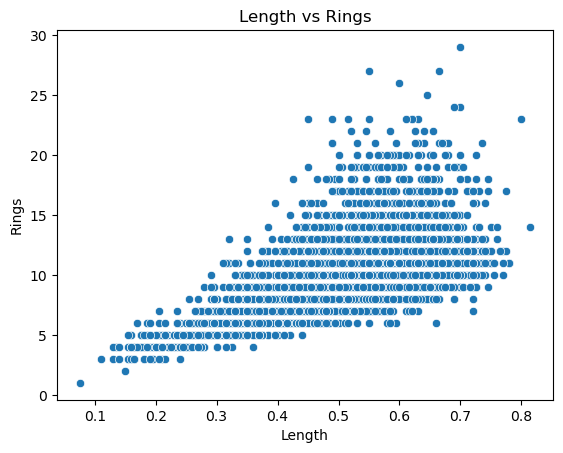

In [99]:
sns.scatterplot(x='Length',y = 'Rings',data = df)
plt.title("Length vs Rings")
plt.show()

In [100]:
from sklearn.model_selection import train_test_split
x = df.drop("Rings", axis =1)
y = df["Rings"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
4037,2,0.550,0.445,0.125,0.672,0.2880,0.1365,0.2100
1272,2,0.475,0.380,0.120,0.441,0.1785,0.0885,0.1505
3384,1,0.475,0.350,0.115,0.487,0.1940,0.1455,0.1250
3160,1,0.335,0.220,0.070,0.170,0.0760,0.0365,0.0500
3894,1,0.595,0.500,0.180,1.053,0.4405,0.1920,0.3900
...,...,...,...,...,...,...,...,...
3444,2,0.495,0.400,0.145,0.578,0.2545,0.1305,0.1645
466,0,0.655,0.530,0.195,1.388,0.5670,0.2735,0.4100
3092,1,0.520,0.430,0.150,0.728,0.3020,0.1575,0.2350
3772,1,0.575,0.460,0.150,0.927,0.3330,0.2070,0.2985


In [101]:
y_test

866     12
1483     9
599     17
1702    10
670     17
        ..
3093     9
1651    10
2897     8
3953     7
1830     6
Name: Rings, Length: 836, dtype: int64

In [102]:
y_train

4037    11
1272     8
3384    13
3160     6
3894    13
        ..
3444     8
466     13
3092    11
3772     9
860     12
Name: Rings, Length: 3340, dtype: int64

In [103]:
x_train

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
4037,2,0.550,0.445,0.125,0.672,0.2880,0.1365,0.2100
1272,2,0.475,0.380,0.120,0.441,0.1785,0.0885,0.1505
3384,1,0.475,0.350,0.115,0.487,0.1940,0.1455,0.1250
3160,1,0.335,0.220,0.070,0.170,0.0760,0.0365,0.0500
3894,1,0.595,0.500,0.180,1.053,0.4405,0.1920,0.3900
...,...,...,...,...,...,...,...,...
3444,2,0.495,0.400,0.145,0.578,0.2545,0.1305,0.1645
466,0,0.655,0.530,0.195,1.388,0.5670,0.2735,0.4100
3092,1,0.520,0.430,0.150,0.728,0.3020,0.1575,0.2350
3772,1,0.575,0.460,0.150,0.927,0.3330,0.2070,0.2985


In [105]:
x.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight',
       'VisceraWeight', 'ShellWeight'],
      dtype='object')

In [106]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4176 entries, 0 to 4175
Series name: Rings
Non-Null Count  Dtype
--------------  -----
4176 non-null   int64
dtypes: int64(1)
memory usage: 32.8 KB


In [107]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [108]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

results = {}
for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f'{name}: MSE = {mse:.2f}, R2 = {r2:.2f}')

Linear Regression: MSE = 4.70, R2 = 0.58
Ridge Regression: MSE = 4.78, R2 = 0.57
Decision Tree: MSE = 9.30, R2 = 0.16
Random Forest: MSE = 4.78, R2 = 0.57


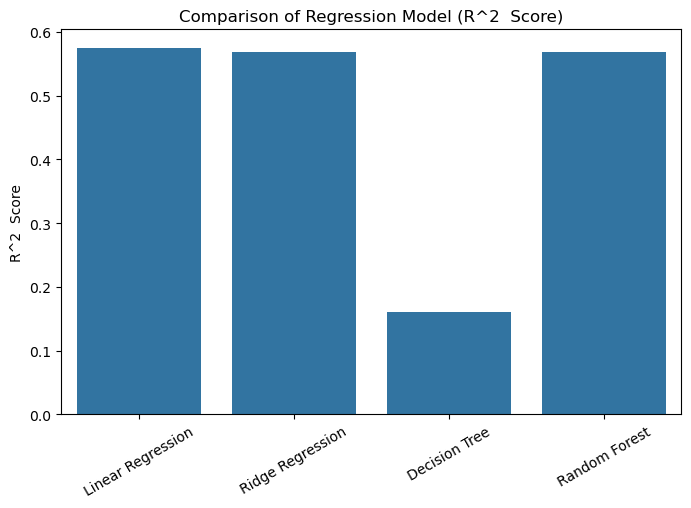

In [109]:
plt.figure(figsize = (8,5))
sns.barplot(x= list(results.keys()), y = list(results.values()))
plt.title("Comparison of Regression Model (R^2  Score)")
plt.ylabel('R^2  Score')
plt.xticks(rotation = 30)
plt.show()

In [110]:
dtr = DecisionTreeRegressor()
dtr.fit(x_train , y_train)
y_pred = dtr.predict(x_test)
print("Decision Tree MSE :- ",mean_squared_error(y_test,y_pred))
print("Decision Tree R2",r2_score(y_test,y_pred))

Decision Tree MSE :-  9.084928229665072
Decision Tree R2 0.17956737155373903


In [111]:
rdm = RandomForestRegressor()
rdm.fit(x_train,y_train, y_train)
y_pred = dtr.predict(x_test)
print("Decision Tree MSE :- ",mean_squared_error(y_test,y_pred))
print("Decision Tree R2",r2_score(y_test,y_pred))

Decision Tree MSE :-  9.084928229665072
Decision Tree R2 0.17956737155373903


In [112]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [113]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [9.]


In [114]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = rdm.predict(features).reshape(1, -1)
    return pred[0]

In [115]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [12.18]


In [116]:
df.tail()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
4171,1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4172,0,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4173,0,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4174,1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4175,0,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [119]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = rdm.predict(features).reshape(1, -1)
    return pred[0]

In [121]:
Sex = 1
Length = 0.565
Diameter = 0.450
Height = 0.165
Whole_weight = 0.8870
Shucked_weight = 0.3700
Viscera_weight = 0.2390
Shell_weight = 0.2490

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [10.94]
